# Notebook 05 — Full Fine-Tuning (FFT)

Full Fine-Tuning of `Qwen2.5-1.5B-Instruct` — all parameters updated.

> **Why 1.5B instead of 3B?** RTX 5070 Laptop has 8 GB VRAM.  
> FFT on 3B requires ~18 GB (weights + optimizer states). The 1.5B model  
> uses ~3 GB weights + ~4 GB optimizer states = fits in 8 GB.  
> This still gives a meaningful LoRA-3B vs FFT-1.5B comparison.

**Trainable params**: 1.54B (100%)  
**Expected VRAM**: ~7 GB  
**Expected time**: ~3-4 hours (3 epochs)

In [1]:
import os
import sys
import gc
import json
from pathlib import Path

# Prevent CUDA allocator fragmentation (other processes share GPU)
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

import torch
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path('..').resolve()))
from src.model_utils import load_model_and_tokenizer, print_model_info
from src.data_utils import load_jsonl_as_hf_dataset
from src.training_utils import build_fft_training_args

from trl import SFTTrainer

ROOT          = Path('..').resolve()
PROCESSED_DIR = ROOT / 'data' / 'processed'
HF_CACHE      = ROOT / 'data' / 'raw' / 'huggingface_cache'
OUTPUT_DIR    = ROOT / 'outputs' / 'exp1' / 'fft'
FIG_DIR       = ROOT / 'outputs' / 'exp1' / 'results' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

MODEL_ID = 'Qwen/Qwen2.5-1.5B-Instruct'

print('Setup complete.')
print(f'GPU:  {torch.cuda.get_device_name(0)}')
print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

Setup complete.
GPU:  NVIDIA RTX PRO 5000 Blackwell
VRAM: 50.8 GB


## 1. Load Datasets

In [2]:
train_dataset = load_jsonl_as_hf_dataset(PROCESSED_DIR / 'train.jsonl')
val_dataset   = load_jsonl_as_hf_dataset(PROCESSED_DIR / 'val.jsonl')
print('Train:', train_dataset)
print('Val:  ', val_dataset)

Train: Dataset({
    features: ['messages'],
    num_rows: 40084
})
Val:   Dataset({
    features: ['messages'],
    num_rows: 2234
})


## 2. Load Model (BF16, All Parameters Trainable)

In [3]:
# 1.5B in BF16 = ~3 GB weights — leaves room for optimizer states on 8 GB
model, tokenizer = load_model_and_tokenizer(
    MODEL_ID,
    quantization=None,           # BF16 full precision
    attn_implementation='eager',
)

print_model_info(model)  # Should show 100% trainable

if torch.cuda.is_available():
    print(f'VRAM after model load: {torch.cuda.memory_allocated(0)/1e9:.2f} GB')
    print('Note: optimizer states add ~2x model size during training')

`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Total parameters:     1,543,714,304
Trainable parameters: 1,543,714,304  (100.00%)
VRAM after model load: 3.09 GB
Note: optimizer states add ~2x model size during training


## 3. Training Configuration (8 GB tuned)

In [4]:
training_args = build_fft_training_args(
output_dir=str(OUTPUT_DIR / 'checkpoints'),
    # ~36 GB effective VRAM (other processes consume ~11 GB of 47 GB)
    per_device_train_batch_size=8, # was 1; OOM at 16 due to ~8 GB logits alloc
    gradient_accumulation_steps=2, # effective batch = 16 preserved
    max_length=512, # was 256; full context
    gradient_checkpointing=True, # reduces activation memory ~40%
    dataloader_num_workers=4, # Linux supports multiprocessing
)

print('Key FFT training arguments:')
print(f' per_device_train_batch_size: {training_args.per_device_train_batch_size}')
print(f' gradient_accumulation_steps: {training_args.gradient_accumulation_steps}')
print(f' effective batch size: {training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps}')
print(f' learning_rate: {training_args.learning_rate} (10x lower than LoRA)')
print(f' optimizer: {training_args.optim}')

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Key FFT training arguments:
 per_device_train_batch_size: 8
 gradient_accumulation_steps: 2
 effective batch size: 16
 learning_rate: 2e-05 (10x lower than LoRA)
 optimizer: OptimizerNames.ADAMW_TORCH_FUSED


## 4. Train

In [5]:
trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
    # No peft_config: full fine-tuning
)

# Check if complete, or find latest checkpoint to resume
_final = OUTPUT_DIR / 'final_model'
if _final.exists():
    print(f'Training already complete — found {_final}')
    print('Delete final_model/ to re-train.')
    train_result = None
else:
    _ckpts = sorted(
        (OUTPUT_DIR / 'checkpoints').glob('checkpoint-*'),
        key=lambda p: int(p.name.split('-')[-1])
    ) if (OUTPUT_DIR / 'checkpoints').exists() else []
    _resume = str(_ckpts[-1]) if _ckpts else None
    print(f'Resuming from: {_resume}' if _resume else 'Starting FFT (Qwen2.5-1.5B) training from scratch ...')
    train_result = trainer.train(resume_from_checkpoint=_resume)
    print(f'\nTraining complete.')
    print(f'  Train loss: {train_result.training_loss:.4f}')
    print(f'  Steps:      {train_result.global_step}')

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Starting FFT (Qwen2.5-1.5B) training from scratch ...


Step,Training Loss,Validation Loss
200,1.109699,1.058284
400,1.067343,1.042514
600,1.016899,1.038985
800,1.015821,1.036301
1000,0.998802,1.038807
1200,0.992628,1.038492
1254,0.983814,1.038912


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['lm_head.weight'].



Training complete.
  Train loss: 1.0815
  Steps:      1254


## 5. Save Full Fine-Tuned Model

In [6]:
model_path = str(OUTPUT_DIR / 'final_model')
trainer.save_model(model_path)
tokenizer.save_pretrained(model_path)
print(f'FFT model saved to: {model_path}')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

FFT model saved to: /home/prasingh/data/Mormon-NLT/outputs/exp1/fft/final_model


In [12]:
log_path = OUTPUT_DIR / 'training_logs' / 'fft_log_history.json'
log_path.parent.mkdir(parents=True, exist_ok=True)
if train_result is not None:
    with open(log_path, 'w') as f:
        json.dump(trainer.state.log_history, f)
    print(f'Log history saved to: {log_path}')
else:
    print('Training was skipped — log not updated.')
    if log_path.exists(): print(f'Existing log at: {log_path}')

Log history saved to: /home/prasingh/data/Mormon-NLT/outputs/exp1/fft/training_logs/fft_log_history.json


## 6. Training Loss Curve

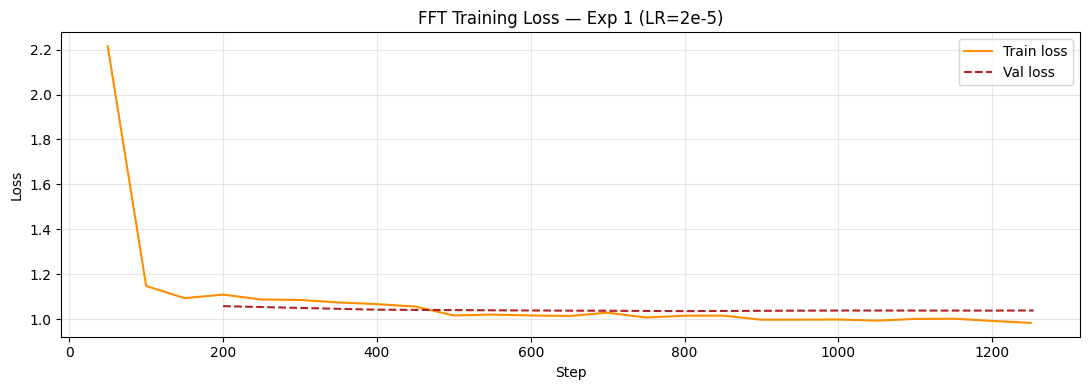

Figure saved to: /home/prasingh/data/Mormon-NLT/outputs/exp1/results/figures/fft_loss_curve.png

Final train loss: 0.9838
Best val loss: 1.0363 (step 800)


In [14]:
with open(log_path) as f:
    log_history = json.load(f)

train_logs = [e for e in log_history if 'loss' in e and 'eval_loss' not in e]
eval_logs = [e for e in log_history if 'eval_loss' in e]

fig, ax = plt.subplots(figsize=(11, 4))
if train_logs:
    ax.plot([e['step'] for e in train_logs], [e['loss'] for e in train_logs],
label='Train loss', color='darkorange', linewidth=1.5)
if eval_logs:
    ax.plot([e['step'] for e in eval_logs], [e['eval_loss'] for e in eval_logs],
label='Val loss', color='firebrick', linestyle='--', linewidth=1.5)
ax.set_xlabel('Step')
ax.set_ylabel('Loss')
ax.set_title('FFT Training Loss — Exp 1 (LR=2e-5)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
out = FIG_DIR / 'fft_loss_curve.png'
fig.savefig(out, dpi=150)
plt.show()
print(f'Figure saved to: {out}')

if train_logs:
    print(f'\nFinal train loss: {train_logs[-1]["loss"]:.4f}')
if eval_logs:
    best = min(eval_logs, key=lambda e: e['eval_loss'])
print(f'Best val loss: {best["eval_loss"]:.4f} (step {best["step"]})')

In [15]:
del model, trainer
gc.collect()
torch.cuda.empty_cache()
print('Memory freed.')

Memory freed.
